# Organoid sorter — real-time control loop

Per frame: snap → segment (Convpaint) → measure class 2 → track (trackpy) → actuate pump by flow speed. On track end: sort by size via eppendorf motor.

All logic lives in the `rtm` package; this notebook is just the driver.

## 1. Config

In [24]:
from pathlib import Path

MODEL_PATH = "model_v3_thursday.pkl"
STORAGE_PATH = "output"           # detections.parquet + detections/ TIFFs land here
MICROMANAGER_PATH = r"C:\Program Files\Micro-Manager-2.0_api75"
CONFIG_PATH = r".\openframe2.cfg"                 # None -> demo config; set to your real .cfg later

N_FRAMES = 20
EXPOSURE_MS = 100
CHANNEL = None                     # e.g. "DAPI" on the demo config

Path(STORAGE_PATH).mkdir(parents=True, exist_ok=True)

## 2. Connect the microscope

In [2]:
from rtm.microscope import Microscope

if CONFIG_PATH is None:
    mic = Microscope.demo(micromanager_path=MICROMANAGER_PATH)
else:
    mic = Microscope(config_path=CONFIG_PATH, micromanager_path=MICROMANAGER_PATH)



In [ ]:
mic.set_exposure(EXPOSURE_MS)
if CHANNEL is not None:
    mic.set_channel(CHANNEL)
mic.mmc.setProperty("CellCam", "Binning","8")

In [25]:
import tifffile
tifffile.imwrite(Path(STORAGE_PATH) / "norg1.tiff", mic.snap())

In [4]:
from napari_micromanager import MainWindow
import napari

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc
viewer.window.add_dock_widget(mm_wdg)


c:\Users\Alex\Desktop\hackathon\code\.venv\Lib\site-packages\napari_micromanager\_util.py:20: FutureWarning: The 'pymmcore_plus.mda.handlers' module is deprecated and will be removed in a future version. We are moving to ome-writers as the internally supported data-sink. If you would like to continue using these handlers, please vendor them into your own codebase.
  from pymmcore_plus.mda.handlers._util import (


## 3. Load the Convpaint model and preview one segmentation

c:\Users\Alex\Desktop\hackathon\code\.venv\Lib\site-packages\napari_convpaint\convpaint_model.py:207: UserWarning: Cellpose is not installed and is not available as feature extractor.
Run 'pip install napari-convpaint[cellpose]' to install it.
  warnings.warn(error_message)
c:\Users\Alex\Desktop\hackathon\code\.venv\Lib\site-packages\napari_convpaint\convpaint_model.py:207: UserWarning: Ilastik is not installed and is not available as feature extractor.
Run 'pip install napari-convpaint[ilastik]' to install it.
Make sure to also have fastfilters installed ('conda install -c ilastik-forge fastfilters').
  warnings.warn(error_message)


FE model is designed for imagenet normalization, but image is not declared as 'rgb' (parameter channel_mode). Using default normalization instead.


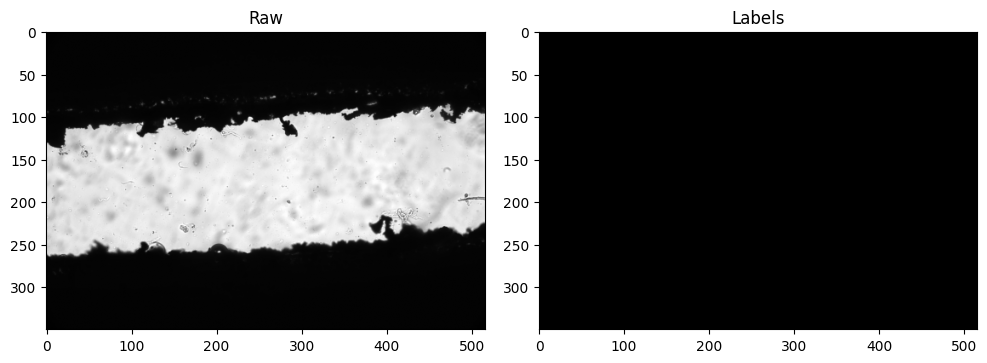

In [27]:
import matplotlib.pyplot as plt
from rtm.segmentation import SegmentationModel

model = SegmentationModel(MODEL_PATH)

test_img = mic.snap()
test_labels = model.segment(test_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Raw")
axes[1].imshow(test_labels, cmap="nipy_spectral")
axes[1].set_title("Labels")
plt.tight_layout()

### Live preview — snap + segment every 2 s (Ctrl+C / stop-cell to exit)

In [ ]:
import time
import os
import tifffile
from IPython.display import clear_output

from rtm.postprocess import clean_and_label, measure_regions

i = 0
tryout = "04"

PREVIEW_INTERVAL_S = 1
CLASS_ID = 2
MIN_PIXEL_SIZE = 50
HOLE_AREA_THRESHOLD = 50

os.makedirs(f"{STORAGE_PATH}/rawstream", exist_ok=True)

try:
    while True:
        img = mic.snap()
        class_labels = model.segment(img)
        cc_labels = clean_and_label(
            class_labels,
            class_id=CLASS_ID,
            min_pixel_size=MIN_PIXEL_SIZE,
            hole_area_threshold=HOLE_AREA_THRESHOLD,
        )
        regions = measure_regions(cc_labels)

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].imshow(img, cmap="gray")
        axes[0].set_title("Raw")
        axes[1].imshow(class_labels, cmap="nipy_spectral")
        axes[1].set_title("Convpaint classes")
        axes[2].imshow(cc_labels, cmap="nipy_spectral")
        axes[2].set_title(f"CC labels (class {CLASS_ID}): {len(regions)} object(s)")
        plt.tight_layout()
        plt.show()
        if not regions.empty:
            print(regions.to_string(index=False))

        tifffile.imwrite(f"{STORAGE_PATH}/rawstream/{tryout}_{i:03d}.tiff", img)
        i += 1
        time.sleep(PREVIEW_INTERVAL_S)
except KeyboardInterrupt:
    print("stopped")

stopped


## 4. Configure the pipeline

**Tracking** (trackpy)
- `search_range` — max pixels an organoid moves between frames.
- `memory` — frames a particle can vanish and still be linked.
- `window_frames` — sliding history for linking; also sets the "exited FOV" timeout (track completes `memory+1` frames after its last observation).
- `min_track_length` — reject one/two-frame flukes.

**Sort decision** (per completed organoid)
- `detection_area_threshold` — minimum *mean* area over the track.
- `size_to_position` — mean area → eppendorf slot. First rule whose `size <= upper_bound` wins.

**Pump** (every frame)
- `speed_aggregator` — e.g. `np.median`, `np.max`. Aggregates per-particle px/frame speeds to one scalar.
- `speed_to_pump` — callable float→int. Default rounds; swap for a proper speed→setpoint map when you have calibration.

In [ ]:
import numpy as np
from rtm.pipeline import Pipeline, PipelineConfig

config = PipelineConfig(
    storage_path=STORAGE_PATH,
    class_id=2,
    min_pixel_size=50,
    hole_area_threshold=50,
    search_range=15.0,
    memory=1,
    window_frames=50,
    min_track_length=3,
    detection_area_threshold=500.0,
    size_to_position=[
        (1000.0, 1),
        (5000.0, 2),
        (float("inf"), 3),
    ],
    speed_aggregator=np.median,
    log_observations=True,
)

pipeline = Pipeline(model=model, config=config)

## 5. Run the acquisition loop

In [ ]:
for t in range(N_FRAMES):
    img = mic.snap()
    result = pipeline.process_frame(img, timestep=t)

    n_tracks = result['tracks']['particle'].nunique() if not result['tracks'].empty else 0
    n_sorted = len(result['sorted'])
    speed = result['speed']
    speed_str = f"{speed:5.2f}" if speed is not None else '  -- '
    print(f"t={t:03d}  tracks={n_tracks:2d}  speed(px/f)={speed_str}  sorted={n_sorted}")

# Flush any organoids still mid-track when the loop ended.
flushed = pipeline.flush(timestep=N_FRAMES - 1)
print(f"flushed {len(flushed)} late-arriving sort decision(s)")

## 6. Inspect the sort log

In [ ]:
import pandas as pd

sorts = pd.read_parquet(config.sorts_parquet)
print(f"{len(sorts)} organoid(s) sorted")
if not sorts.empty:
    print(sorts['sort_position'].value_counts().sort_index().to_string())
sorts.head()

In [ ]:
# Per-frame observations (if logging is on)
if config.log_observations and Path(config.observations_parquet).exists():
    obs = pd.read_parquet(config.observations_parquet)
    print(f"{len(obs)} observation rows across {obs['frame'].nunique()} frames")
    obs.head()